In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
gold = pd.read_csv("Gold 100years.csv")

gold.head()

,Date,Value
0,01/01/1915,19.25
1,02/01/1915,19.25
2,03/01/1915,19.25
3,04/01/1915,19.25
4,05/01/1915,19.25


In [3]:
gold.columns

Index(['Date', 'Value'], dtype='object')

In [4]:
gold['Date'] = pd.to_datetime(gold['Date'])

gold_missing = gold.isnull().sum().sum()

gold_duplicate = gold['Date'].duplicated().sum()

print("Missing Values:", gold_missing)
print("Duplicate Dates:", gold_duplicate)

Missing Values: 0
Duplicate Dates: 0


In [5]:
brent = pd.read_csv("Brent Oil.csv")

brent.head()

,Date,Value
0,01/01/1946,21.23
1,02/01/1946,21.35
2,03/01/1946,21.11
3,04/01/1946,22.79
4,05/01/1946,22.67


In [6]:
brent.columns

Index(['Date', 'Value'], dtype='object')

In [7]:
brent['Date'] = pd.to_datetime(brent['Date'])

brent_missing = brent.isnull().sum().sum()

brent_duplicate = brent['Date'].duplicated().sum()

print("Missing Values:", brent_missing)
print("Duplicate Dates:", brent_duplicate)

Missing Values: 0
Duplicate Dates: 0


In [8]:
quality = pd.DataFrame({
    "Dataset":["Gold","Brent Oil"],
    "Missing Values":[gold_missing,brent_missing],
    "Duplicate Dates":[gold_duplicate,brent_duplicate]
})

quality

,Dataset,Missing Values,Duplicate Dates
0,Gold,0,0
1,Brent Oil,0,0


In [9]:
gold['Year'] = gold['Date'].dt.year

In [11]:
# CELL 10 - B11 (Top 5 Years with Highest Average Gold Price)

import pandas as pd

# Ensure Date column is datetime
gold.iloc[:, 0] = pd.to_datetime(gold.iloc[:, 0], errors='coerce')

# Create Year column
gold['Year'] = gold.iloc[:, 0].dt.year

# Automatically detect price/value column
price_col = gold.columns[1]

# Convert price column to numeric
gold[price_col] = pd.to_numeric(gold[price_col], errors='coerce')

# Calculate top 5 years
top5_gold = (
    gold.groupby('Year')[price_col]
        .mean()
        .reset_index()
        .sort_values(by=price_col, ascending=False)
        .head(5)
)

# Rename columns for cleaner output
top5_gold.columns = ['Year', 'Average Gold Price']

print("Top 5 Years with Highest Average Gold Price")
display(top5_gold)

Top 5 Years with Highest Average Gold Price


,Year,Average Gold Price
111,2026,4881.619800
110,2025,3472.540975
109,2024,2404.577567
108,2023,1953.688517
107,2022,1798.956575


In [12]:
top5_gold.to_csv(
    "B11_Top5_Gold_Years.csv",
    index=False
)

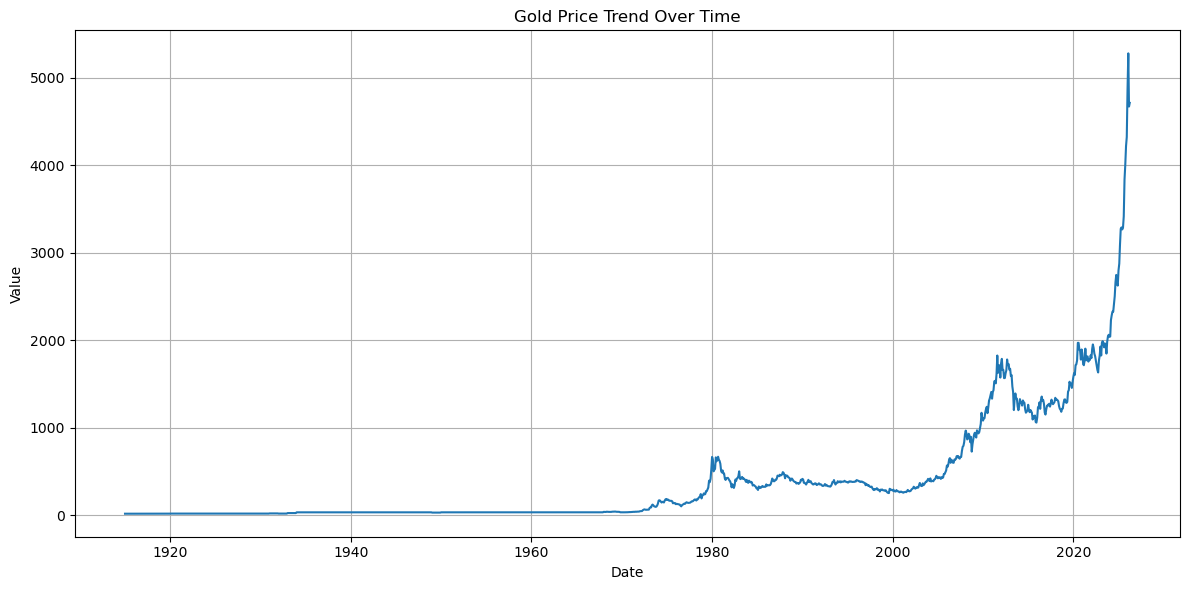

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Automatically detect columns
date_col = gold.columns[0]
price_col = gold.columns[1]

# Convert data types
gold[date_col] = pd.to_datetime(gold[date_col], errors='coerce')
gold[price_col] = pd.to_numeric(gold[price_col], errors='coerce')

# Remove invalid rows
gold = gold.dropna(subset=[date_col, price_col])

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    gold[date_col],
    gold[price_col]
)

plt.title("Gold Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel(price_col)

plt.grid(True)
plt.tight_layout()

plt.show()

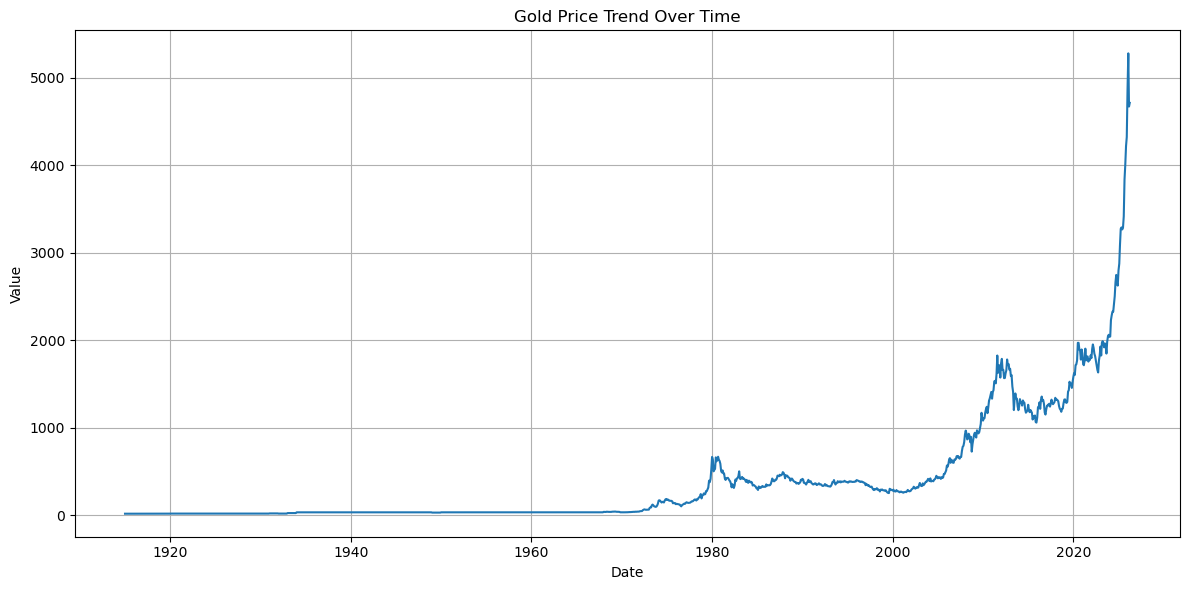

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    gold[date_col],
    gold[price_col]
)

plt.title("Gold Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel(price_col)

plt.grid(True)
plt.tight_layout()

plt.savefig("Gold_Price_Trend.png", dpi=300)

plt.show()

In [17]:
# D26 - Compare Latest Brent Oil Value with Long-Term Average

import pandas as pd

# First column = Date
date_col = brent.columns[0]

# Second column = Brent value
value_col = brent.columns[1]

# Convert data types
brent[date_col] = pd.to_datetime(brent[date_col], errors='coerce')
brent[value_col] = pd.to_numeric(brent[value_col], errors='coerce')

# Remove invalid rows
brent = brent.dropna(subset=[date_col, value_col])

# Latest value
latest_value = brent.sort_values(date_col).iloc[-1][value_col]

# Long-term average
average_value = brent[value_col].mean()

print("Latest Brent Oil Value =", round(latest_value, 2))
print("Long-Term Average =", round(average_value, 2))

Latest Brent Oil Value = 102.86
Long-Term Average = 62.71


In [23]:
comparison = pd.DataFrame({
    "Latest Brent Value": [round(latest_value, 2)],
    "Long-Term Average": [round(average_value, 2)],
    "Difference": [round(latest_value - average_value, 2)],
    "Status": [
        "Above Average"
        if latest_value > average_value
        else "Below Average"
    ]
})

comparison

,Latest Brent Value,Long-Term Average,Difference,Status
0,102.86,62.71,40.15,Above Average


In [24]:
comparison.to_csv(
    "D26_Brent_Comparison.csv",
    index=False
)

print("File saved successfully!")

File saved successfully!


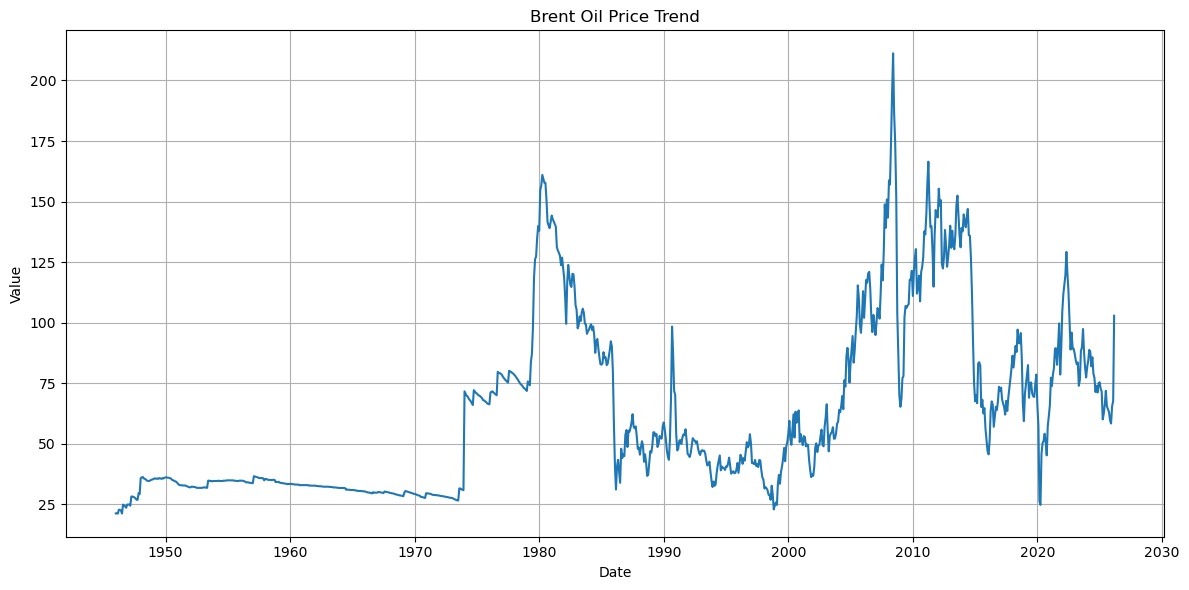

In [26]:
# Cell 17 - Brent Oil Trend Chart (0-error version)

import matplotlib.pyplot as plt
import pandas as pd

# Automatically detect columns
date_col = brent.columns[0]
value_col = brent.columns[1]

# Convert data
brent[date_col] = pd.to_datetime(brent[date_col], errors='coerce')
brent[value_col] = pd.to_numeric(brent[value_col], errors='coerce')

# Remove invalid rows
brent = brent.dropna(subset=[date_col, value_col])

# Create chart
plt.figure(figsize=(12,6))

plt.plot(
    brent[date_col],
    brent[value_col]
)

plt.title("Brent Oil Price Trend")
plt.xlabel("Date")
plt.ylabel(value_col)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "Brent_Oil_Trend.png",
    dpi=300
)

plt.show()